In [1]:
import pandas as pd
from pycaret.classification import *
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import optunahub
import optuna

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [2]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')
data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] != gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


In [3]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


## GK


### Base Model


In [4]:
g_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[g_cs_features]
g_cs_data_tar = g_cs_data_tar[g_cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

clean_sheets
0.0    1206
1.0     369
Name: count, dtype: int64


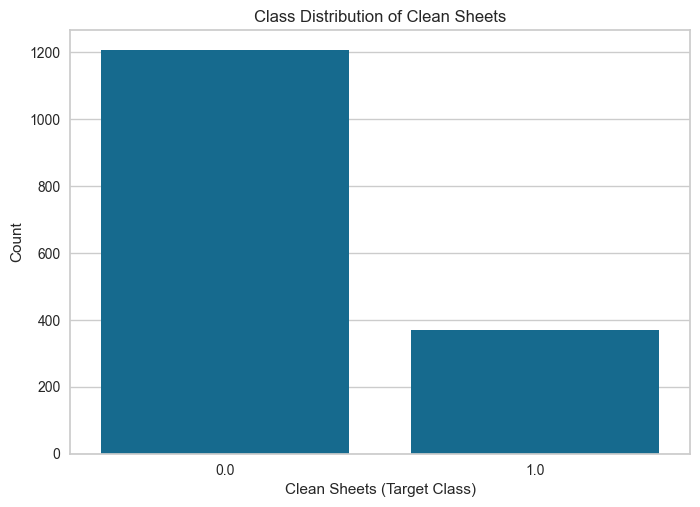

In [5]:
print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

In [ ]:
base_g_cs_model = setup(g_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_cs_best = base_g_cs_model.compare_models(sort='AUC')
base_g_cs_best

[LightGBM] [Info] Number of positive: 965, number of negative: 965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.927572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10955
[LightGBM] [Info] Number of data points in the train set: 1930, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3580
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(2245, 24)"
5,Transformed train set shape,"(1930, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,18:28:01
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Ridge Classifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5698,0.5556,0.5015,0.2715,0.3504,0.0702,0.0793,49.8480
nb,Naive Bayes,0.4960,0.5224,0.5732,0.2481,0.3453,0.0301,0.0395,18.0510
svm,SVM - Linear Kernel,0.5389,0.5129,0.4032,0.2224,0.2819,-0.0155,-0.0159,17.5540
knn,K Neighbors Classifier,0.4651,0.5107,0.5698,0.2351,0.3323,0.0019,0.0022,46.8890
dt,Decision Tree Classifier,0.6016,0.4913,0.2841,0.2247,0.2501,-0.0150,-0.0155,17.8780


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
evaluate_model(base_g_cs_best)

NameError: name 'evaluate_model' is not defined

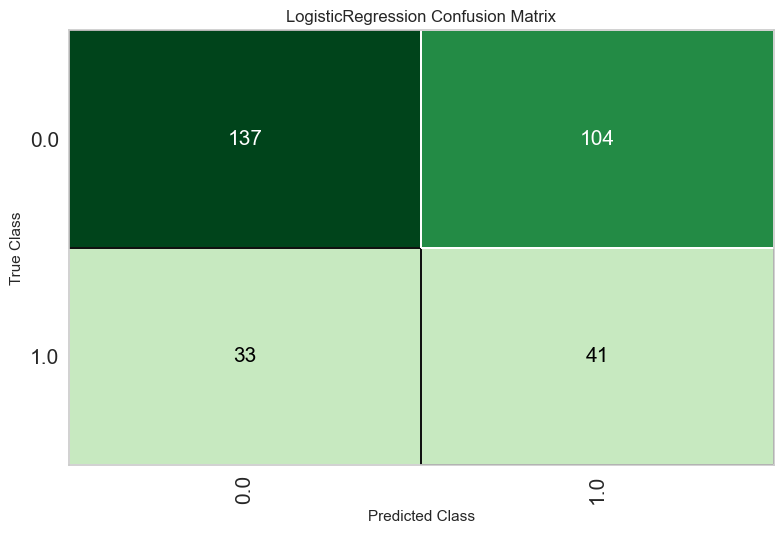

In [ ]:
plot_model(base_g_cs_best, plot='confusion_matrix')

### Tuned Model


In [ ]:
# Enhanced setup for better performance
tuned_g_cs_model = setup(g_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_cs_best = tuned_g_cs_model.compare_models(n_select=3, sort='F1')
g_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(881, 58)"
5,Transformed train set shape,"(524, 58)"
6,Transformed test set shape,"(315, 58)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.6111,0.5598,0.4347,0.2846,0.3432,0.0843,0.0884,0.3530
lr,Logistic Regression,0.5929,0.5314,0.4308,0.2698,0.3306,0.0608,0.0644,0.2700
lda,Linear Discriminant Analysis,0.5794,0.5470,0.4343,0.2633,0.3270,0.0488,0.0512,0.3820
knn,K Neighbors Classifier,0.4802,0.5059,0.5078,0.2293,0.3150,-0.0119,-0.0175,0.2300
svm,SVM - Linear Kernel,0.5786,0.5032,0.4033,0.2536,0.3099,0.0309,0.0320,0.2900
lightgbm,Light Gradient Boosting Machine,0.6937,0.5777,0.3054,0.3212,0.3065,0.1147,0.1163,0.5240
xgboost,Extreme Gradient Boosting,0.6849,0.5885,0.2978,0.3195,0.3030,0.1028,0.1044,0.3860
dt,Decision Tree Classifier,0.6000,0.5162,0.3590,0.2542,0.2966,0.0300,0.0301,0.2700
ada,Ada Boost Classifier,0.6302,0.5335,0.3259,0.2585,0.2867,0.0417,0.0430,0.5740
gbc,Gradient Boosting Classifier,0.6690,0.5433,0.2608,0.2738,0.2644,0.0533,0.0536,0.5530


[RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_state=123, solver='auto',
                 tol=0.0001),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001)]

In [ ]:
# Ensemble (blend or stack)
g_cs_blended = blend_models(g_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6429,0.0000,0.4483,0.3095,0.3662,0.1290,0.1333
1,0.5952,0.0000,0.4828,0.2800,0.3544,0.0890,0.0960
2,0.5556,0.0000,0.4828,0.2545,0.3333,0.0457,0.0510
3,0.5714,0.0000,0.6552,0.3016,0.4130,0.1429,0.1697
4,0.6429,0.0000,0.5172,0.3261,0.4000,0.1640,0.1728
5,0.6349,0.0000,0.4333,0.3095,0.3611,0.1154,0.1186
6,0.5635,0.0000,0.4000,0.2449,0.3038,0.0120,0.0127
7,0.5476,0.0000,0.4000,0.2353,0.2963,-0.0050,-0.0054
8,0.5873,0.0000,0.4333,0.2708,0.3333,0.0570,0.0603


In [ ]:
g_cs_tuned = tune_model(g_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6270,0.0000,0.3793,0.2750,0.3188,0.0709,0.0727
1,0.6349,0.0000,0.3793,0.2821,0.3235,0.0809,0.0825
2,0.6349,0.0000,0.4483,0.3023,0.3611,0.1189,0.1234
3,0.5794,0.0000,0.5862,0.2931,0.3908,0.1211,0.1381
4,0.6746,0.0000,0.6207,0.3750,0.4675,0.2533,0.2699
5,0.5556,0.0000,0.4000,0.2400,0.3000,0.0034,0.0036
6,0.4603,0.0000,0.2000,0.1200,0.1500,-0.2102,-0.2249
7,0.6111,0.0000,0.3000,0.2432,0.2687,0.0077,0.0078
8,0.5714,0.0000,0.5333,0.2857,0.3721,0.0899,0.1000


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


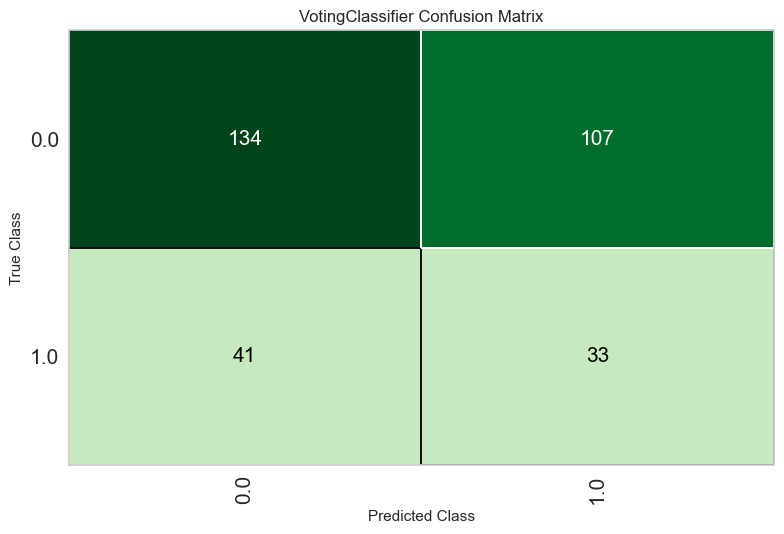

In [ ]:
plot_model(g_cs_tuned, plot='confusion_matrix')

In [ ]:
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_cs_tuned, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.5302,0.5010,0.4459,0.2357,0.3084,0.0015,0.0017


In [ ]:
# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [ ]:
evaluate_model(g_cs_tuned)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [ ]:
g_cs_final_model = finalize_model(g_cs_tuned)


In [ ]:
save_model(g_cs_final_model, 'g_cs_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                   penalty='l2',
                     

## Def


In [ ]:
d_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[d_cs_features]
def_cs_data_tar = def_cs_data_tar[d_cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0.0    5054
1.0    1401
Name: count, dtype: int64


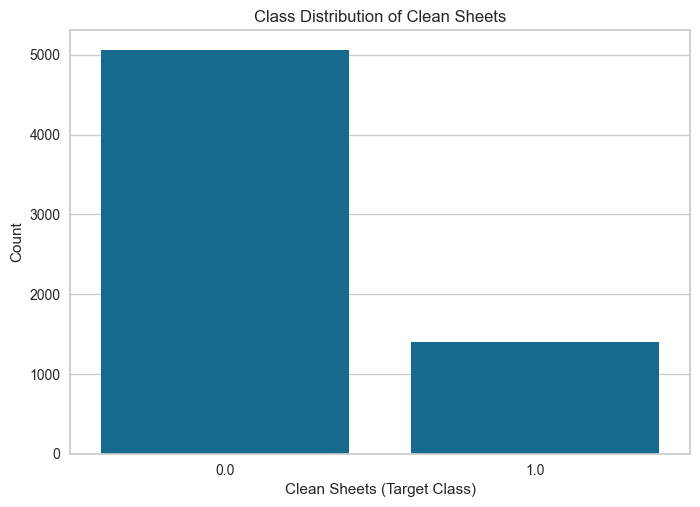

In [ ]:
print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [ ]:
base_def_cs_model = setup(def_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_cs_best = base_def_cs_model.compare_models(sort='AUC')
base_def_cs_best

[LightGBM] [Info] Number of positive: 4043, number of negative: 4043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16750
[LightGBM] [Info] Number of data points in the train set: 8086, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,1975
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(9377, 24)"
5,Transformed train set shape,"(8086, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8639,0.8721,0.4764,0.8238,0.6028,0.5277,0.5570,1.5460
rf,Random Forest Classifier,0.8505,0.8484,0.3585,0.8835,0.5093,0.4394,0.5021,2.1450
xgboost,Extreme Gradient Boosting,0.8402,0.8189,0.3864,0.7618,0.5104,0.4275,0.4636,1.2930
lightgbm,Light Gradient Boosting Machine,0.8242,0.8146,0.2649,0.7796,0.3947,0.3202,0.3847,1.3130
knn,K Neighbors Classifier,0.6115,0.7371,0.7752,0.3318,0.4646,0.2305,0.2817,0.9470
gbc,Gradient Boosting Classifier,0.7854,0.6767,0.0607,0.5452,0.1083,0.0689,0.1244,3.1440
dt,Decision Tree Classifier,0.7407,0.6452,0.4764,0.4161,0.4441,0.2761,0.2772,1.0920
ridge,Ridge Classifier,0.6106,0.6345,0.5691,0.2942,0.3877,0.1426,0.1597,1.2690
lr,Logistic Regression,0.6055,0.6331,0.5700,0.2911,0.3851,0.1375,0.1547,1.0830
lda,Linear Discriminant Analysis,0.6117,0.6329,0.5674,0.2949,0.3878,0.1434,0.1601,0.9060


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=1975, verbose=0,
                     warm_start=False)

In [ ]:
evaluate_model(base_def_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_def_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8807,0.8915,0.5000,0.9091,0.6452,0.5806,0.6181


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
5263,0.135,0.206,0.658,True,3.0,1.0,27512.0,-0.499588,1.8,17.799999,...,1.8,1.8,2.4,0.40,0.40,1.78,0.0,0,0.71,0.29
1057,0.565,0.255,0.180,True,2.0,4.0,55857.0,0.280376,6.5,24.799999,...,0.8,0.8,2.8,0.29,0.27,4.56,0.0,0,0.52,0.48
1707,0.819,0.126,0.055,False,2.0,5.0,-766.0,-0.642559,1.2,12.400000,...,2.8,2.0,0.2,0.09,0.09,2.58,0.0,0,0.90,0.10
6202,NaN,NaN,NaN,True,4.0,3.0,297.0,0.078222,1.4,13.000000,...,0.8,0.8,4.2,0.13,0.11,NaN,0.0,0,0.84,0.16
2182,0.456,0.247,0.297,True,3.0,2.0,30221.0,0.125182,0.0,0.000000,...,0.4,1.2,4.2,0.25,0.25,3.78,0.0,0,0.98,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,0.291,0.270,0.439,True,4.0,4.0,-12228.0,-0.758136,1.7,14.200000,...,1.8,2.8,0.4,0.17,0.15,1.62,0.0,0,0.72,0.28
2051,0.693,0.189,0.118,False,3.0,4.0,-36654.0,-0.802008,4.0,21.799999,...,2.0,2.0,2.8,0.27,0.25,2.66,1.0,1,0.46,0.54
2536,0.405,0.274,0.321,False,2.0,3.0,-8631.0,-0.692308,4.6,13.000000,...,1.4,1.4,3.2,0.24,0.08,1.68,1.0,0,0.68,0.32
6136,0.791,0.136,0.073,False,3.0,5.0,614.0,0.305263,2.1,17.400000,...,1.2,1.4,4.6,0.39,0.39,1.84,0.0,0,0.87,0.13


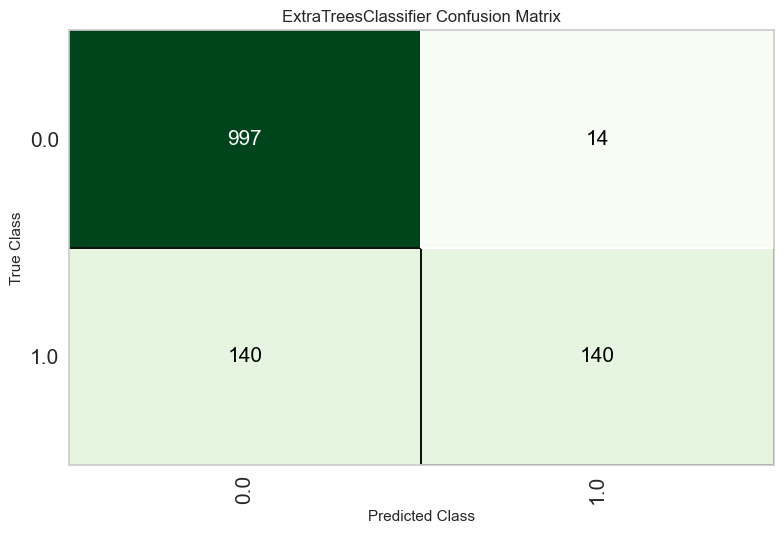

In [ ]:
plot_model(base_def_cs_best, plot='confusion_matrix')

In [ ]:
base_def_cs_tuned = tune_model(base_def_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5977,0.5810,0.4554,0.2576,0.3290,0.0723,0.0783
1,0.6267,0.6400,0.6071,0.3134,0.4134,0.1787,0.1997
2,0.6634,0.6609,0.4464,0.3086,0.3650,0.1463,0.1509
3,0.5899,0.6105,0.5133,0.2698,0.3537,0.0941,0.1045
4,0.6337,0.6542,0.5357,0.3046,0.3883,0.1543,0.1668
5,0.6550,0.6875,0.5982,0.3350,0.4295,0.2095,0.2276
6,0.6376,0.6093,0.4018,0.2727,0.3249,0.0895,0.0926
7,0.6085,0.6072,0.4286,0.2581,0.3221,0.0702,0.0747
8,0.5891,0.5764,0.5357,0.2727,0.3614,0.1036,0.1164


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
save_model(base_def_cs_tuned, 'def_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned Model


In [ ]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_def_cs_model = setup(def_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_cs_best = tuned_def_cs_model.compare_models(n_select=3, sort='F1')
def_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4341, 66)"
5,Transformed train set shape,"(3065, 66)"
6,Transformed test set shape,"(1291, 66)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7004,0.6959,0.4951,0.3628,0.4180,0.2233,0.2285,0.9050
lightgbm,Light Gradient Boosting Machine,0.7320,0.6963,0.4113,0.3890,0.3990,0.2271,0.2276,1.1790
xgboost,Extreme Gradient Boosting,0.7277,0.6906,0.4131,0.3814,0.3959,0.2207,0.2214,1.0260
rf,Random Forest Classifier,0.7082,0.6833,0.4184,0.3558,0.3841,0.1949,0.1961,1.2990
knn,K Neighbors Classifier,0.4171,0.6052,0.8287,0.2477,0.3814,0.0710,0.1226,0.6060
lda,Linear Discriminant Analysis,0.5017,0.6153,0.7074,0.2610,0.3811,0.0939,0.1278,0.5880
ridge,Ridge Classifier,0.4952,0.6121,0.7056,0.2579,0.3776,0.0876,0.1197,0.7350
lr,Logistic Regression,0.5012,0.6102,0.6905,0.2579,0.3754,0.0868,0.1164,0.6850
dt,Decision Tree Classifier,0.6425,0.5883,0.4924,0.3026,0.3745,0.1443,0.1527,0.6320
svm,SVM - Linear Kernel,0.5225,0.5774,0.6406,0.2574,0.3666,0.0837,0.1086,0.7180


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 XGBClassifier(

In [ ]:
# Ensemble (blend or stack)
def_cs_blended = blend_models(def_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6905,0.6269,0.3661,0.3154,0.3388,0.1383,0.1389
1,0.7485,0.7526,0.4286,0.4211,0.4248,0.2639,0.2639
2,0.7369,0.6900,0.3839,0.3909,0.3874,0.2199,0.2199
3,0.7408,0.7300,0.3717,0.4000,0.3853,0.2214,0.2216
4,0.7326,0.7477,0.5268,0.4097,0.4609,0.2868,0.2908
5,0.7267,0.6927,0.3482,0.3645,0.3562,0.1828,0.1829
6,0.7306,0.7259,0.4464,0.3937,0.4184,0.2440,0.2448
7,0.7326,0.6966,0.4464,0.3968,0.4202,0.2471,0.2479
8,0.7345,0.7260,0.4196,0.3950,0.4069,0.2361,0.2363


In [ ]:
def_cs_tuned = tune_model(def_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6847,0.6410,0.3661,0.3083,0.3347,0.1301,0.1309
1,0.7582,0.7388,0.4732,0.4454,0.4589,0.3034,0.3036
2,0.7369,0.6932,0.3929,0.3929,0.3929,0.2250,0.2250
3,0.7350,0.7242,0.3894,0.3929,0.3911,0.2218,0.2218
4,0.7539,0.7519,0.4821,0.4390,0.4596,0.3007,0.3012
5,0.7326,0.6844,0.3929,0.3860,0.3894,0.2182,0.2182
6,0.7326,0.7029,0.3661,0.3796,0.3727,0.2028,0.2029
7,0.7403,0.7005,0.4554,0.4113,0.4322,0.2644,0.2650
8,0.7364,0.7089,0.4196,0.3983,0.4087,0.2393,0.2394


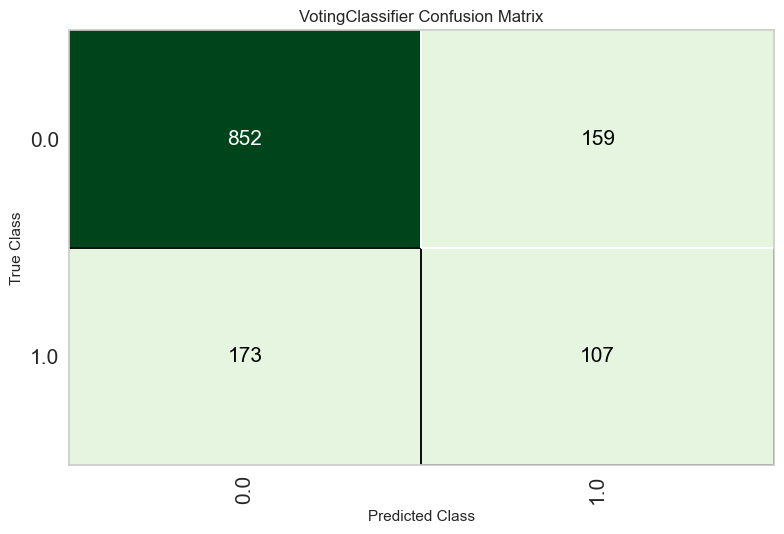

In [ ]:
plot_model(def_cs_tuned, plot='confusion_matrix')

## Mid


In [ ]:
mid_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[mid_cs_features]
mid_cs_data_tar = mid_cs_data_tar[mid_cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0.0    5054
1.0    1401
Name: count, dtype: int64


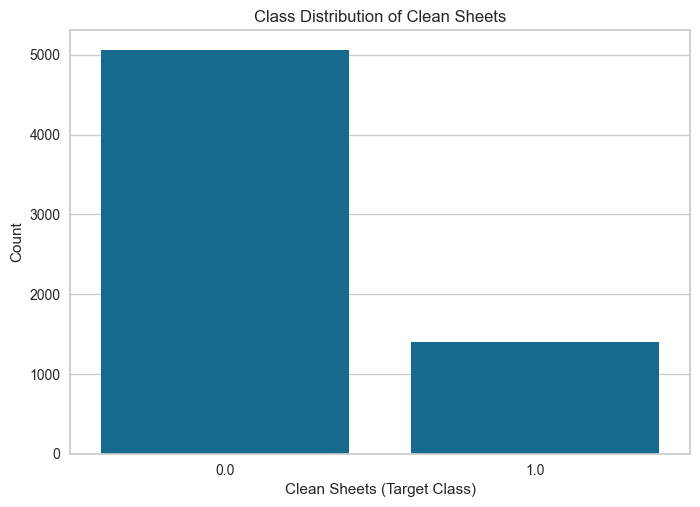

In [ ]:
print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base


In [ ]:
base_mid_cs_model = setup(mid_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_cs_best = base_mid_cs_model.compare_models(sort='AUC')
base_mid_cs_best

[LightGBM] [Info] Number of positive: 4043, number of negative: 4043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17526
[LightGBM] [Info] Number of data points in the train set: 8086, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,4488
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(9377, 24)"
5,Transformed train set shape,"(8086, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8689,0.8773,0.5209,0.8086,0.6307,0.5560,0.5775,1.7860
rf,Random Forest Classifier,0.8472,0.8519,0.3514,0.8600,0.4952,0.4249,0.4852,2.8270
xgboost,Extreme Gradient Boosting,0.8433,0.8235,0.4085,0.7562,0.5290,0.4456,0.4765,1.3330
lightgbm,Light Gradient Boosting Machine,0.8273,0.8083,0.2783,0.7914,0.4108,0.3362,0.3999,1.2760
knn,K Neighbors Classifier,0.6015,0.7445,0.7699,0.3245,0.4564,0.2173,0.2681,1.0260
gbc,Gradient Boosting Classifier,0.7831,0.6724,0.0419,0.5318,0.0770,0.0456,0.0968,3.0670
dt,Decision Tree Classifier,0.7423,0.6449,0.4728,0.4185,0.4434,0.2768,0.2780,0.9750
ridge,Ridge Classifier,0.5978,0.6220,0.5736,0.2869,0.3822,0.1308,0.1483,1.0660
lda,Linear Discriminant Analysis,0.5968,0.6219,0.5602,0.2833,0.3760,0.1235,0.1394,1.0280
lr,Logistic Regression,0.5949,0.6167,0.5709,0.2843,0.3793,0.1263,0.1435,0.9350


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=4488, verbose=0,
                     warm_start=False)

In [ ]:
evaluate_model(base_mid_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_mid_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8714,0.8843,0.4929,0.8519,0.6244,0.5534,0.5836


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
4591,0.467,0.259,0.274,False,3.0,3.0,975.0,0.160478,4.0,39.599998,...,1.8,3.0,3.6,0.54,0.50,3.08,0.0,0,0.87,0.13
2835,0.544,0.242,0.214,True,2.0,2.0,1977.0,0.616944,4.8,23.000000,...,1.2,2.4,1.8,0.10,0.02,0.28,0.0,0,0.79,0.21
4541,0.510,0.242,0.248,False,2.0,4.0,-22373.0,-0.437101,3.5,5.800000,...,1.4,1.4,1.4,0.29,0.27,2.00,0.0,0,0.79,0.21
6346,0.510,0.248,0.242,False,3.0,3.0,2675.0,0.068079,1.9,10.200000,...,1.8,1.2,4.0,0.58,0.48,4.00,1.0,1,0.47,0.53
600,0.530,0.252,0.218,True,3.0,4.0,133623.0,0.602834,1.4,11.200000,...,1.8,1.2,3.0,0.23,0.21,4.00,0.0,0,0.70,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761,0.269,0.261,0.470,False,3.0,2.0,39279.0,0.712252,2.8,15.600000,...,1.2,3.4,2.2,0.38,0.33,1.48,0.0,0,0.52,0.48
6303,0.615,0.214,0.171,False,2.0,3.0,-2561.0,-0.281724,4.1,26.600000,...,1.8,1.6,1.0,0.16,0.16,NaN,0.0,0,0.87,0.13
5521,0.575,0.219,0.206,True,3.0,4.0,25799.0,0.704121,1.7,8.400000,...,2.2,0.4,3.2,0.25,0.25,NaN,0.0,0,0.63,0.37
4043,0.470,0.261,0.269,False,2.0,2.0,-1172.0,-0.069875,4.7,26.600000,...,1.2,2.0,1.4,0.38,0.31,1.48,0.0,0,0.64,0.36


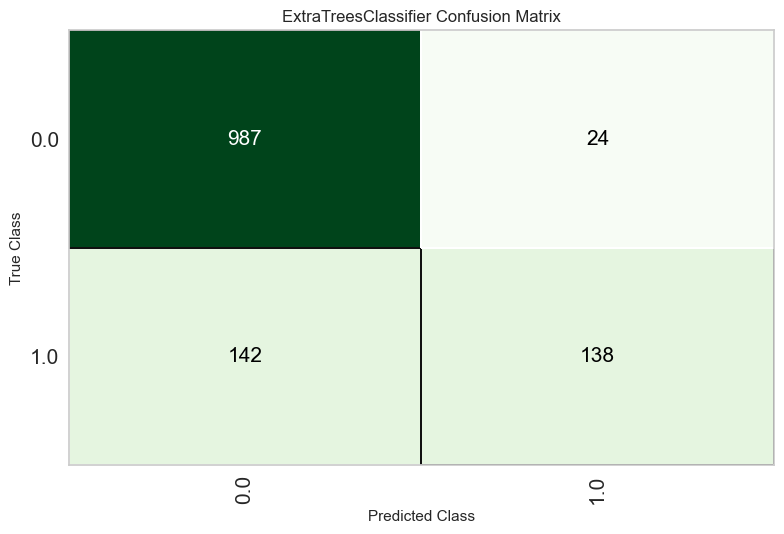

In [ ]:

plot_model(base_mid_cs_best, plot='confusion_matrix')

In [ ]:
base_mid_cs_tuned = tune_model(base_mid_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7292,0.6980,0.3451,0.3714,0.3578,0.1865,0.1867
1,0.7737,0.7125,0.3929,0.4731,0.4293,0.2896,0.2916
2,0.7350,0.7114,0.4464,0.4000,0.4219,0.2507,0.2514
3,0.7447,0.7143,0.5446,0.4296,0.4803,0.3142,0.3181
4,0.7946,0.7634,0.4464,0.5319,0.4854,0.3583,0.3605
5,0.7422,0.7050,0.3304,0.3895,0.3575,0.1976,0.1987
6,0.7674,0.7114,0.3750,0.4565,0.4118,0.2686,0.2706
7,0.7694,0.7485,0.3750,0.4615,0.4138,0.2722,0.2744
8,0.7655,0.7106,0.3393,0.4471,0.3858,0.2442,0.2478


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
save_model(base_mid_cs_best, 'mid_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned


In [ ]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_mid_cs_model = setup(mid_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_cs_best = tuned_mid_cs_model.compare_models(n_select=3, sort='F1')
mid_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4417, 66)"
5,Transformed train set shape,"(3126, 66)"
6,Transformed test set shape,"(1291, 66)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.6973,0.6938,0.5005,0.3603,0.4182,0.2215,0.2273,0.9550
rf,Random Forest Classifier,0.7095,0.6791,0.4273,0.3604,0.3898,0.2017,0.2034,1.3120
lightgbm,Light Gradient Boosting Machine,0.7262,0.6877,0.3997,0.3807,0.3883,0.2128,0.2136,1.1830
lr,Logistic Regression,0.5064,0.6177,0.7172,0.2650,0.3868,0.1023,0.1387,1.2340
lda,Linear Discriminant Analysis,0.5135,0.6168,0.7065,0.2663,0.3865,0.1042,0.1396,0.7000
xgboost,Extreme Gradient Boosting,0.7248,0.6864,0.3907,0.3755,0.3820,0.2055,0.2060,1.0540
ridge,Ridge Classifier,0.5050,0.6165,0.7029,0.2615,0.3810,0.0948,0.1285,0.5590
dt,Decision Tree Classifier,0.6431,0.5893,0.4942,0.3021,0.3747,0.1447,0.1538,0.6660
knn,K Neighbors Classifier,0.3943,0.5851,0.8172,0.2387,0.3694,0.0503,0.0888,0.7770
gbc,Gradient Boosting Classifier,0.6900,0.6552,0.4086,0.3298,0.3642,0.1629,0.1648,2.3260


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, n_estimators=100, n_jobs=-1,
                        oob_scor

In [ ]:
# Ensemble (blend or stack)
mid_cs_blended = blend_models(mid_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7195,0.6286,0.3750,0.3590,0.3668,0.1868,0.1869
1,0.7447,0.7425,0.4643,0.4194,0.4407,0.2758,0.2764
2,0.7350,0.6919,0.3750,0.3853,0.3801,0.2116,0.2116
3,0.7582,0.7346,0.4336,0.4455,0.4395,0.2854,0.2854
4,0.7422,0.7633,0.4286,0.4103,0.4192,0.2537,0.2538
5,0.7403,0.6911,0.4107,0.4035,0.4071,0.2408,0.2409
6,0.7578,0.7048,0.4107,0.4381,0.4240,0.2708,0.2710
7,0.7287,0.7081,0.4732,0.3955,0.4309,0.2546,0.2564
8,0.7112,0.6886,0.4286,0.3609,0.3918,0.2043,0.2056


In [ ]:
mid_cs_tuned = tune_model(mid_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6770,0.5863,0.3125,0.2800,0.2954,0.0866,0.0869
1,0.7292,0.7504,0.4286,0.3871,0.4068,0.2319,0.2324
2,0.7369,0.7021,0.4286,0.4000,0.4138,0.2445,0.2447
3,0.7369,0.7263,0.4248,0.4034,0.4138,0.2444,0.2445
4,0.7481,0.7544,0.5536,0.4366,0.4882,0.3242,0.3282
5,0.7422,0.7010,0.3929,0.4037,0.3982,0.2342,0.2343
6,0.7597,0.7153,0.4196,0.4434,0.4312,0.2790,0.2792
7,0.7287,0.7076,0.4821,0.3971,0.4355,0.2591,0.2612
8,0.7771,0.7275,0.4911,0.4867,0.4889,0.3464,0.3464


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


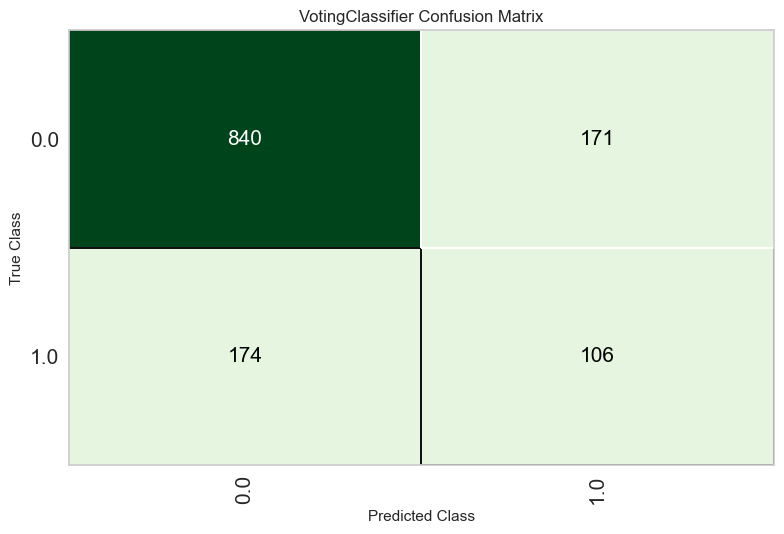

In [ ]:
plot_model(mid_cs_tuned, plot='confusion_matrix')

# Yellow cards


## GK


### Base Model


In [ ]:
g_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[g_y_features]
g_y_data_tar = g_y_data_tar[g_y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


yellow_cards
0.0    1459
1.0     116
Name: count, dtype: int64


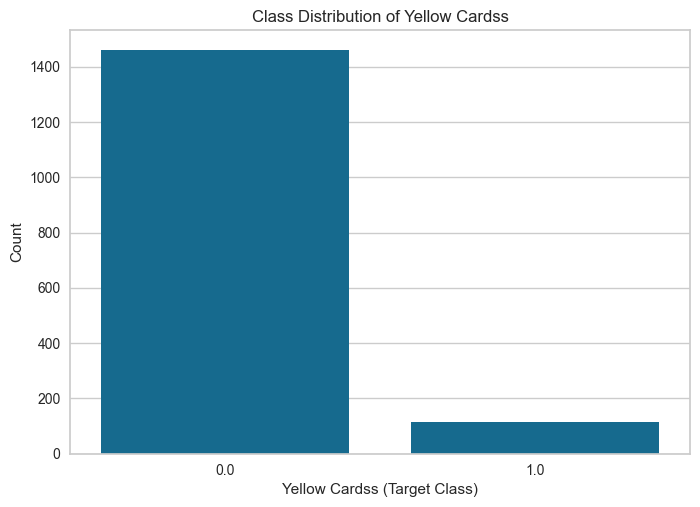

In [ ]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

yellow_cards
0.0    1459
1.0     116
Name: count, dtype: int64


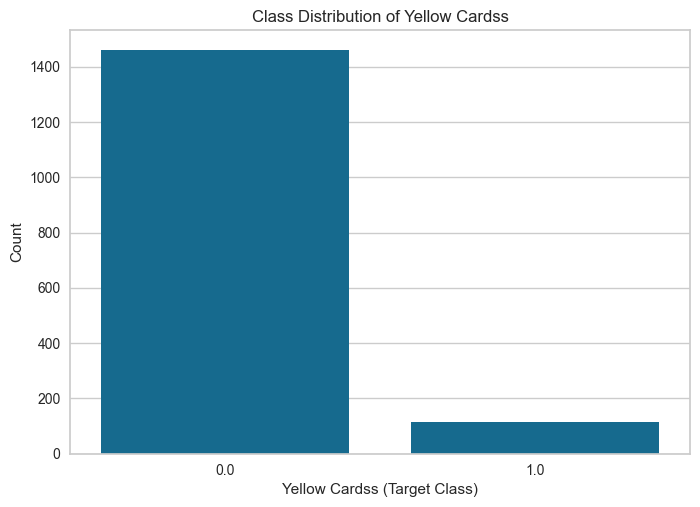

[LightGBM] [Info] Number of positive: 1167, number of negative: 1167
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12485
[LightGBM] [Info] Number of data points in the train set: 2334, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3937
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(2649, 24)"
5,Transformed train set shape,"(2334, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.6040,0.5244,0.4122,0.0787,0.1318,0.0094,0.0160,0.4870
gbc,Gradient Boosting Classifier,0.9198,0.5239,0.0111,0.0500,0.0182,0.0058,0.0073,1.3170
rf,Random Forest Classifier,0.9175,0.5077,0.0100,0.0500,0.0167,-0.0000,-0.0000,0.9680
dummy,Dummy Classifier,0.9262,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5260
ridge,Ridge Classifier,0.6103,0.4918,0.3344,0.0682,0.1130,-0.0109,-0.0178,0.4880
lightgbm,Light Gradient Boosting Machine,0.9183,0.4904,0.0211,0.0533,0.0297,0.0136,0.0126,0.8200
xgboost,Extreme Gradient Boosting,0.9127,0.4871,0.0000,0.0000,0.0000,-0.0220,-0.0300,0.6410
dt,Decision Tree Classifier,0.8230,0.4831,0.0844,0.0515,0.0637,-0.0285,-0.0289,0.4950
svm,SVM - Linear Kernel,0.5325,0.4830,0.4378,0.0674,0.1163,-0.0115,-0.0116,0.6990
lr,Logistic Regression,0.6048,0.4783,0.3544,0.0693,0.1155,-0.0084,-0.0117,0.4920


LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

In [ ]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_g_y_model = setup(g_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_y_best = base_g_y_model.compare_models(sort='AUC')
base_g_y_best

In [ ]:
evaluate_model(base_g_y_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

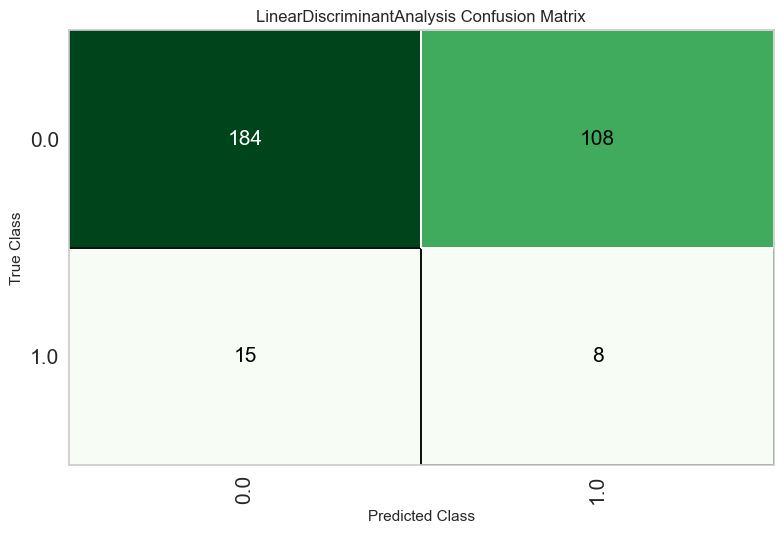

In [ ]:
plot_model(base_g_y_best, plot='confusion_matrix')

### Tuned Model


In [ ]:
# Enhanced setup for better performance
tuned_g_y_model = setup(g_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_y_best = tuned_g_y_model.compare_models(n_select=3, sort='F1')
g_y_best

KeyError: "['was_home'] not in index"

In [ ]:


# Ensemble (blend or stack)
g_y_blended = blend_models(g_y_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8333,0.0000,0.2222,0.1250,0.1600,0.0755,0.0793
1,0.8492,0.0000,0.4444,0.2222,0.2963,0.2222,0.2390
2,0.8730,0.0000,0.2222,0.1818,0.2000,0.1318,0.1326
3,0.8571,0.0000,0.2222,0.1538,0.1818,0.1064,0.1085
4,0.8571,0.0000,0.1111,0.0909,0.1000,0.0233,0.0234
5,0.8254,0.0000,0.2222,0.1176,0.1538,0.0667,0.0709
6,0.8492,0.0000,0.1111,0.0833,0.0952,0.0148,0.0150
7,0.8016,0.0000,0.1000,0.0588,0.0741,-0.0287,-0.0300
8,0.8571,0.0000,0.2000,0.1667,0.1818,0.1043,0.1048


In [ ]:

g_y_tuned = tune_model(g_y_blended, search_library='optuna', optimize='F1')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7381,0.0000,0.1111,0.0385,0.0571,-0.0548,-0.0653
1,0.8016,0.0000,0.5556,0.1923,0.2857,0.2009,0.2393
2,0.8810,0.0000,0.2222,0.2000,0.2105,0.1463,0.1466
3,0.7698,0.0000,0.3333,0.1154,0.1714,0.0731,0.0870
4,0.7698,0.0000,0.2222,0.0833,0.1212,0.0193,0.0224
5,0.7222,0.0000,0.3333,0.0938,0.1463,0.0392,0.0506
6,0.8095,0.0000,0.4444,0.1739,0.2500,0.1642,0.1880
7,0.7619,0.0000,0.0000,0.0000,0.0000,-0.1183,-0.1275
8,0.7540,0.0000,0.2000,0.0800,0.1143,0.0010,0.0012


In [ ]:
plot_model(g_y_tuned, plot='confusion_matrix')

In [ ]:
# pcc.plot_model(tuned, plot='threshold')
preds_blend = predict_model(g_y_blended, raw_score=True)

# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_y_tuned, raw_score=True)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.8476,0.5974,0.3043,0.1795,0.2258,0.1475,0.1538


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.7905,0.5465,0.2609,0.1091,0.1538,0.0567,0.0638


In [ ]:

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [ ]:
evaluate_model(g_y_blended)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [ ]:
g_y_final_model = finalize_model(g_y_blended)
save_model(g_y_final_model, 'g_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                           max_features=None,
        

## Def


### Base Model


In [ ]:
d_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[d_y_features]
def_y_data_tar = def_y_data_tar[d_y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

yellow_cards
0.0    5483
1.0     972
Name: count, dtype: int64


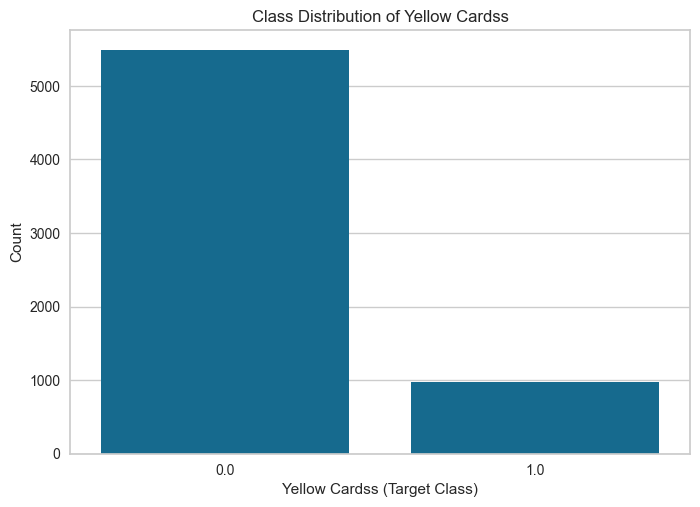

[LightGBM] [Info] Number of positive: 4386, number of negative: 4386
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17754
[LightGBM] [Info] Number of data points in the train set: 8772, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,2626
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(10063, 24)"
5,Transformed train set shape,"(8772, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4582,0.5404,0.6659,0.1696,0.2703,0.0397,0.0635,1.6960
lr,Logistic Regression,0.5321,0.5470,0.5373,0.1693,0.2572,0.0365,0.0492,2.4170
ridge,Ridge Classifier,0.5347,0.5411,0.5297,0.1683,0.2552,0.0346,0.0468,1.0700
qda,Quadratic Discriminant Analysis,0.5126,0.5371,0.5490,0.1645,0.2530,0.0279,0.0395,1.0810
lda,Linear Discriminant Analysis,0.5302,0.5377,0.5193,0.1647,0.2498,0.0275,0.0370,1.2330
knn,K Neighbors Classifier,0.4649,0.5230,0.5721,0.1550,0.2438,0.0088,0.0129,1.0500
svm,SVM - Linear Kernel,0.4874,0.5020,0.5360,0.1543,0.2384,0.0073,0.0108,1.1170
dt,Decision Tree Classifier,0.7078,0.5050,0.2148,0.1566,0.1807,0.0084,0.0087,1.1390
ada,Ada Boost Classifier,0.8033,0.5295,0.0604,0.1472,0.0760,-0.0061,-0.0057,1.6250
et,Extra Trees Classifier,0.8313,0.5422,0.0360,0.1956,0.0596,0.0126,0.0192,1.8980


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4681,0.5265,0.6410,0.1684,0.2667,0.0364,0.0567
1,0.4584,0.5181,0.6026,0.1588,0.2513,0.0165,0.0256
2,0.4623,0.5401,0.7051,0.1774,0.2835,0.0559,0.0908
3,0.4313,0.4930,0.5513,0.1424,0.2263,-0.0177,-0.0281
4,0.4961,0.5876,0.7051,0.1884,0.2973,0.0771,0.1185
5,0.4612,0.5298,0.6282,0.1644,0.2606,0.0277,0.0433
6,0.4496,0.5353,0.6923,0.1720,0.2755,0.0440,0.0724
7,0.4574,0.5234,0.6410,0.1656,0.2632,0.0301,0.0478
8,0.4283,0.5841,0.7273,0.1697,0.2752,0.0438,0.0765


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_def_y_model = setup(def_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_y_best = base_def_y_model.compare_models(sort='F1')
base_def_y_best

print('Tuning the model...')
def_y_base_tuned = tune_model(base_def_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

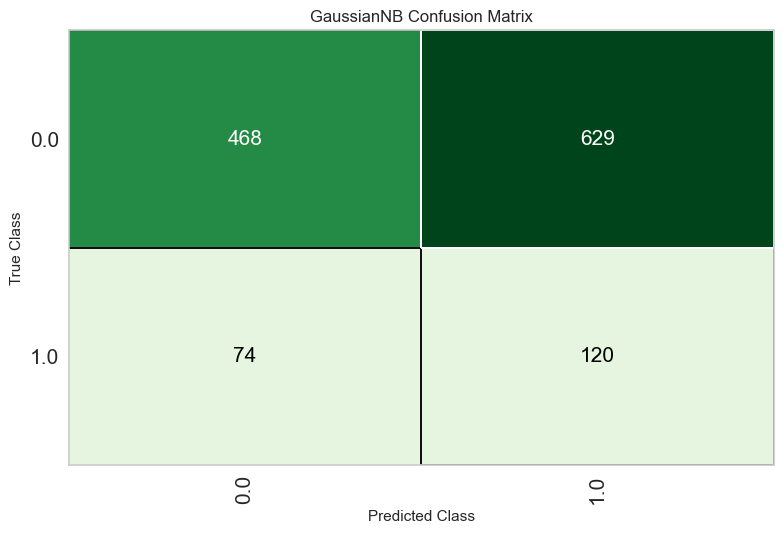

In [ ]:
evaluate_model(base_def_y_best)
plot_model(base_def_y_best, plot='confusion_matrix')

### Blended Model


In [ ]:
# Enhanced setup for better performance
tuned_def_y_model = setup(def_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_y_best = tuned_def_y_model.compare_models(n_select=3, sort='F1')
print(def_y_best)

print('Blended model')
# Ensemble (blend or stack)
def_y_blended = blend_models(def_y_best, optimize='F1')

def_y_tuned = tune_model(def_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4943, 65)"
5,Transformed train set shape,"(3652, 65)"
6,Transformed test set shape,"(1291, 65)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.3383,0.5204,0.7929,0.1594,0.2654,0.0193,0.0417,0.8020
lda,Linear Discriminant Analysis,0.3542,0.5273,0.7611,0.1583,0.2619,0.0168,0.0348,0.8350
dummy,Dummy Classifier,0.1507,0.5000,1.0000,0.1507,0.2619,0.0000,0.0000,0.6710
nb,Naive Bayes,0.4826,0.5461,0.6067,0.1666,0.2613,0.0325,0.0483,0.9060
ridge,Ridge Classifier,0.3424,0.5221,0.7700,0.1570,0.2608,0.0141,0.0297,0.8500
lr,Logistic Regression,0.3495,0.5264,0.7585,0.1569,0.2600,0.0138,0.0286,0.8490
svm,SVM - Linear Kernel,0.3848,0.5241,0.7109,0.1576,0.2579,0.0151,0.0294,1.0060
qda,Quadratic Discriminant Analysis,0.6354,0.5399,0.3830,0.1779,0.2394,0.0442,0.0496,1.0220
ada,Ada Boost Classifier,0.6861,0.5316,0.2970,0.1777,0.2219,0.0412,0.0433,1.6300
dt,Decision Tree Classifier,0.6472,0.5073,0.3072,0.1582,0.2083,0.0117,0.0122,1.2690


[KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform'), LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001), DummyClassifier(constant=None, random_state=123, strategy='prior')]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2321,0.4800,0.8590,0.1479,0.2524,-0.0068,-0.0221
1,0.2959,0.5137,0.8590,0.1595,0.2691,0.0196,0.0503
2,0.2650,0.5401,0.9231,0.1614,0.2748,0.0242,0.0740
3,0.2592,0.5309,0.8590,0.1526,0.2592,0.0040,0.0116
4,0.2500,0.5396,0.8333,0.1481,0.2515,-0.0071,-0.0207
5,0.2461,0.4962,0.8077,0.1442,0.2447,-0.0160,-0.0459
6,0.2481,0.5422,0.9744,0.1645,0.2815,0.0308,0.1089
7,0.2616,0.5076,0.8590,0.1533,0.2602,0.0049,0.0142
8,0.2791,0.5254,0.9091,0.1609,0.2734,0.0266,0.0761


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3133,0.4750,0.7308,0.1458,0.2431,-0.0113,-0.0251
1,0.3424,0.5149,0.7436,0.1534,0.2544,0.0057,0.0118
2,0.3153,0.5629,0.8590,0.1634,0.2746,0.0282,0.0686
3,0.3153,0.5216,0.7949,0.1550,0.2594,0.0092,0.0213
4,0.3159,0.5357,0.7949,0.1554,0.2600,0.0095,0.0218
5,0.2946,0.5197,0.7949,0.1512,0.2541,0.0001,0.0003
6,0.2965,0.5324,0.9359,0.1694,0.2868,0.0415,0.1145
7,0.3159,0.4962,0.7949,0.1554,0.2600,0.0095,0.0218
8,0.2965,0.5656,0.8312,0.1546,0.2607,0.0121,0.0303


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [ ]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
def_y_final_model = finalize_model(base_g_y_best)
save_model(def_y_final_model, 'def_y_final_model')

NameError: name 'base_g_y_best' is not defined

## Mid


In [ ]:
mid_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[mid_y_features]
mid_y_data_tar = mid_y_data_tar[mid_y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


### Base Model


yellow_cards
0.0    5780
1.0    1057
Name: count, dtype: int64


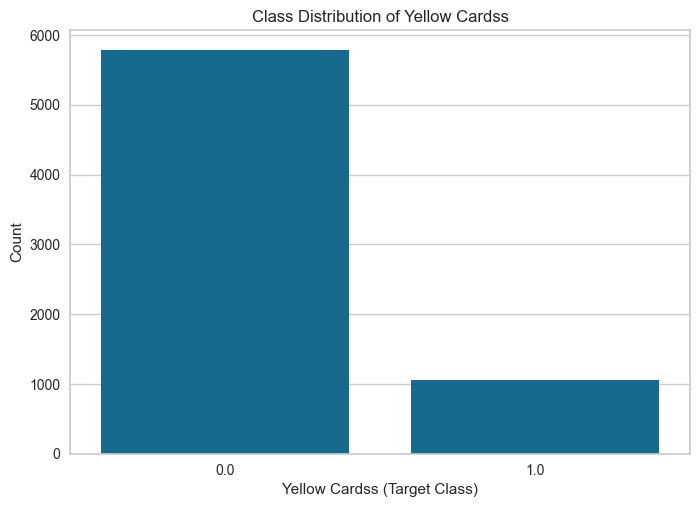

[LightGBM] [Info] Number of positive: 4623, number of negative: 4623
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014910 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16701
[LightGBM] [Info] Number of data points in the train set: 9246, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,8360
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6837, 116)"
4,Transformed data shape,"(10614, 24)"
5,Transformed train set shape,"(9246, 24)"
6,Transformed test set shape,"(1368, 24)"
7,Numeric features,114
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5731,0.5839,0.5448,0.1913,0.2830,0.0702,0.0898,1.3600
nb,Naive Bayes,0.4366,0.5691,0.7128,0.1752,0.2813,0.0439,0.0742,0.9050
lr,Logistic Regression,0.5703,0.5817,0.5388,0.1887,0.2794,0.0654,0.0838,2.1780
lda,Linear Discriminant Analysis,0.5650,0.5811,0.5234,0.1830,0.2710,0.0544,0.0700,1.4010
svm,SVM - Linear Kernel,0.5054,0.5654,0.5932,0.1755,0.2704,0.0420,0.0600,1.4120
qda,Quadratic Discriminant Analysis,0.5173,0.5586,0.5498,0.1709,0.2606,0.0323,0.0443,1.3410
knn,K Neighbors Classifier,0.4599,0.5324,0.6086,0.1641,0.2585,0.0196,0.0302,1.0740
dt,Decision Tree Classifier,0.7222,0.5171,0.2199,0.1766,0.1954,0.0302,0.0306,1.3610
xgboost,Extreme Gradient Boosting,0.8254,0.5583,0.0413,0.1879,0.0664,0.0145,0.0189,1.6280
et,Extra Trees Classifier,0.8219,0.5735,0.0319,0.1506,0.0520,-0.0022,-0.0027,1.8780


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5521,0.5612,0.4286,0.1545,0.2271,0.0018,0.0022
1,0.5521,0.5689,0.5238,0.1767,0.2643,0.0449,0.0587
2,0.5338,0.5944,0.5476,0.1749,0.2651,0.0422,0.0570
3,0.5210,0.5670,0.6000,0.1828,0.2802,0.0551,0.0772
4,0.5759,0.5853,0.5176,0.1872,0.2750,0.0606,0.0763
5,0.5759,0.5904,0.5059,0.1845,0.2704,0.0553,0.0693
6,0.5686,0.5426,0.4588,0.1703,0.2484,0.0281,0.0349
7,0.5850,0.5992,0.5647,0.2017,0.2972,0.0885,0.1121
8,0.5576,0.5639,0.5529,0.1873,0.2798,0.0620,0.0810


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_mid_y_model = setup(mid_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_y_best = base_mid_y_model.compare_models(sort='F1')
base_mid_y_best

print('Tuning the model...')
mid_y_base_tuned = tune_model(base_mid_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

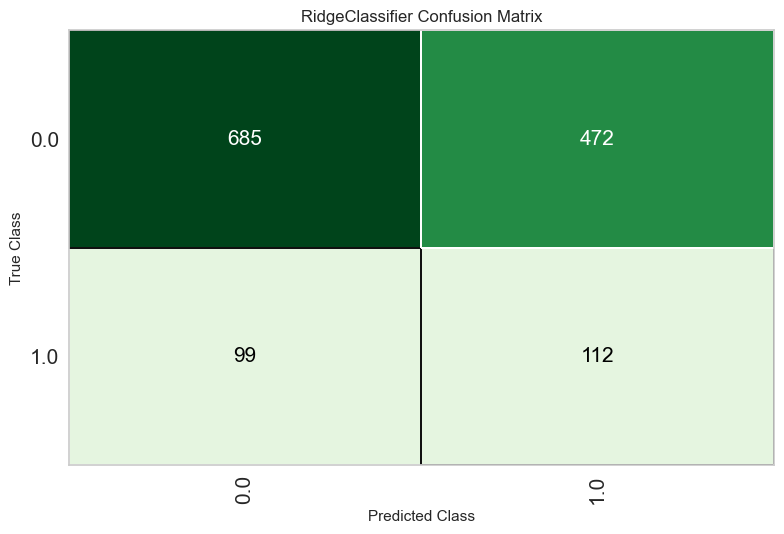

In [ ]:
evaluate_model(base_mid_y_best)
plot_model(base_mid_y_best, plot='confusion_matrix')

### Blended Model


In [ ]:
# Convert all boolean columns to int to avoid numpy WRITEABLE flag error
for col in mid_y_data.select_dtypes(include='bool').columns:
    mid_y_data[col] = mid_y_data[col].astype(int)

# Enhanced setup for better performance
tuned_mid_y_model = setup(mid_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_y_best = tuned_mid_y_model.compare_models( sort='F1')
print(mid_y_best)

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6837, 116)"
4,Transformed data shape,"(5945, 67)"
5,Transformed train set shape,"(4577, 67)"
6,Transformed test set shape,"(1368, 67)"
7,Numeric features,115
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.4061,0.6004,0.7979,0.1801,0.2938,0.0553,0.1030,1.0470
lda,Linear Discriminant Analysis,0.4248,0.6005,0.7707,0.1808,0.2929,0.0565,0.1013,1.0660
lr,Logistic Regression,0.4114,0.5978,0.7813,0.1789,0.2911,0.0527,0.0969,4.3950
nb,Naive Bayes,0.5368,0.5920,0.6075,0.1896,0.2889,0.0694,0.0952,1.6920
svm,SVM - Linear Kernel,0.4418,0.5634,0.7163,0.1779,0.2845,0.0491,0.0808,1.7580
knn,K Neighbors Classifier,0.3383,0.5529,0.8204,0.1668,0.2772,0.0271,0.0600,1.6890
ada,Ada Boost Classifier,0.6762,0.5880,0.3911,0.2090,0.2714,0.0881,0.0955,1.4620
qda,Quadratic Discriminant Analysis,0.5632,0.5600,0.5236,0.1865,0.2708,0.0573,0.0711,1.0510
dummy,Dummy Classifier,0.1547,0.5000,1.0000,0.1547,0.2679,0.0000,0.0000,1.2400
et,Extra Trees Classifier,0.7031,0.6011,0.3499,0.2159,0.2667,0.0936,0.0980,1.6500


RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=123, solver='auto',
                tol=0.0001)


### Save Model


In [ ]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
mid_y_final_model = finalize_model(mid_y_best)
save_model(mid_y_final_model, 'mid_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha', 'was_home',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', '...
                                                                                  sampling_strategy='

## FWD


In [ ]:
fwd_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home',  'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[fwd_y_features]
fwd_y_data_tar = fwd_y_data_tar[fwd_y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

### Base Model


yellow_cards
0.0    1359
1.0     181
Name: count, dtype: int64


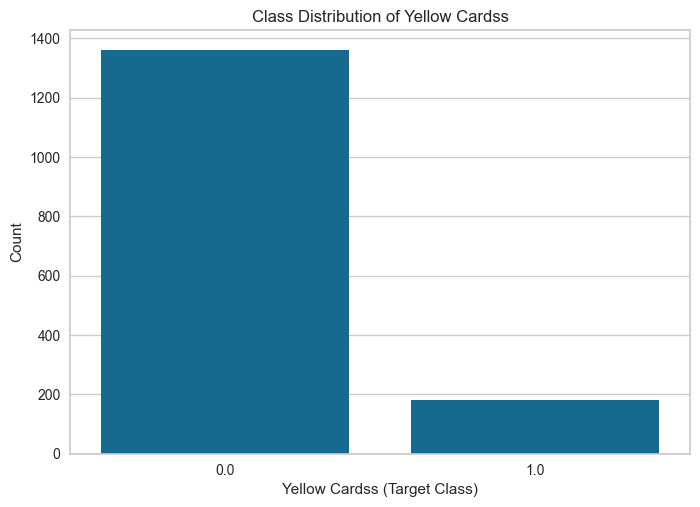

[LightGBM] [Info] Number of positive: 1087, number of negative: 1087
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16600
[LightGBM] [Info] Number of data points in the train set: 2174, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,2028
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1540, 116)"
4,Transformed data shape,"(2482, 24)"
5,Transformed train set shape,"(2174, 24)"
6,Transformed test set shape,"(308, 24)"
7,Numeric features,114
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.6072,0.5556,0.4805,0.1458,0.2232,0.0526,0.0695,1.2280
ridge,Ridge Classifier,0.5982,0.5375,0.4938,0.1433,0.2217,0.0496,0.0691,1.1640
lr,Logistic Regression,0.5917,0.5408,0.4652,0.1352,0.2093,0.0344,0.0482,2.4650
nb,Naive Bayes,0.5163,0.5120,0.5214,0.1254,0.2019,0.0156,0.0244,0.8590
knn,K Neighbors Classifier,0.4578,0.5062,0.5390,0.1156,0.1902,-0.0044,-0.0099,1.0260
svm,SVM - Linear Kernel,0.5242,0.5111,0.4400,0.1146,0.1811,-0.0070,-0.0153,1.0510
qda,Quadratic Discriminant Analysis,0.6713,0.5166,0.2686,0.1157,0.1610,-0.0032,-0.0044,1.0340
dt,Decision Tree Classifier,0.7508,0.5030,0.1790,0.1144,0.1386,0.0007,0.0015,1.0830
ada,Ada Boost Classifier,0.7954,0.4828,0.1229,0.1324,0.1270,0.0120,0.0118,1.1990
gbc,Gradient Boosting Classifier,0.8612,0.5013,0.0338,0.1700,0.0515,0.0091,0.0182,1.7820


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5484,0.6361,0.4667,0.1273,0.2000,0.0122,0.0173
1,0.6290,0.6550,0.5333,0.1702,0.2581,0.0914,0.1180
2,0.5691,0.4600,0.3571,0.1020,0.1587,-0.0223,-0.0302
3,0.6341,0.4220,0.2143,0.0811,0.1176,-0.0569,-0.0676
4,0.4878,0.5301,0.5714,0.1231,0.2025,0.0187,0.0309
5,0.6016,0.5524,0.5000,0.1429,0.2222,0.0549,0.0744
6,0.5772,0.4142,0.3571,0.1042,0.1613,-0.0181,-0.0243
7,0.5610,0.5840,0.5333,0.1455,0.2286,0.0457,0.0646
8,0.5772,0.5519,0.5333,0.1509,0.2353,0.0558,0.0771


In [ ]:
print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_fwd_y_model = setup(fwd_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_fwd_y_best = base_fwd_y_model.compare_models(sort='F1')
base_fwd_y_best

print('Tuning the model...')
fwd_y_base_tuned = tune_model(base_fwd_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

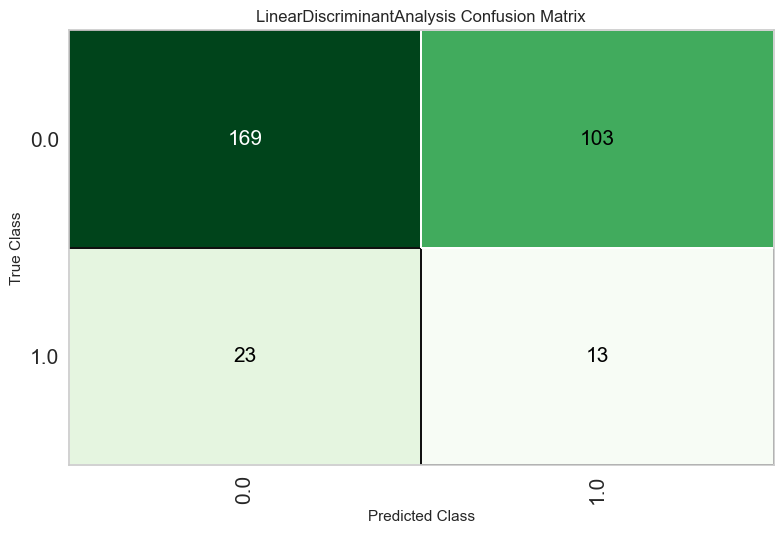

In [ ]:
evaluate_model(base_fwd_y_best)
plot_model(base_fwd_y_best, plot='confusion_matrix')

### Blended Model


In [ ]:
# Enhanced setup for better performance
tuned_fwd_y_model = setup(fwd_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

fwd_y_best = tuned_fwd_y_model.compare_models(n_select=3, sort='F1')
print(fwd_y_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_y_blended = blend_models(fwd_y_best, optimize='F1')

fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1540, 116)"
4,Transformed data shape,"(996, 61)"
5,Transformed train set shape,"(710, 61)"
6,Transformed test set shape,"(308, 61)"
7,Numeric features,114
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.1177,0.5000,1.0000,0.1177,0.2106,0.0000,0.0000,0.4220
ridge,Ridge Classifier,0.5365,0.5231,0.5033,0.1272,0.2027,0.0188,0.0286,0.5150
svm,SVM - Linear Kernel,0.5722,0.5132,0.4495,0.1268,0.1970,0.0176,0.0249,0.8330
knn,K Neighbors Classifier,0.3742,0.5066,0.6471,0.1151,0.1953,-0.0053,-0.0102,0.7780
qda,Quadratic Discriminant Analysis,0.3505,0.5174,0.7062,0.1503,0.1841,0.0169,0.0213,0.5250
lr,Logistic Regression,0.5641,0.4834,0.4071,0.1152,0.1792,-0.0044,-0.0054,0.5750
lda,Linear Discriminant Analysis,0.5349,0.4867,0.4095,0.1088,0.1713,-0.0176,-0.0254,0.5880
dt,Decision Tree Classifier,0.6997,0.4958,0.2290,0.1126,0.1494,-0.0074,-0.0073,0.5260
ada,Ada Boost Classifier,0.7556,0.4822,0.1710,0.1325,0.1460,0.0108,0.0102,1.0000
gbc,Gradient Boosting Classifier,0.8311,0.5245,0.0952,0.1537,0.1152,0.0287,0.0304,1.3380


[DummyClassifier(constant=None, random_state=123, strategy='prior'), RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=123, solver='auto',
                tol=0.0001), SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=123, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4355,0.0000,0.4667,0.1014,0.1667,-0.0400,-0.0670
1,0.4435,0.0000,0.7333,0.1447,0.2418,0.0498,0.0917
2,0.4878,0.0000,0.5714,0.1231,0.2025,0.0187,0.0309
3,0.4797,0.0000,0.7143,0.1429,0.2381,0.0597,0.1051
4,0.3659,0.0000,0.4286,0.0789,0.1333,-0.0729,-0.1396
5,0.4472,0.0000,0.5714,0.1143,0.1905,0.0010,0.0017
6,0.4228,0.0000,0.7143,0.1299,0.2198,0.0336,0.0654
7,0.4065,0.0000,0.7333,0.1375,0.2316,0.0330,0.0648
8,0.5610,0.0000,0.4667,0.1321,0.2059,0.0195,0.0269


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.1210,0.0000,1.0000,0.1210,0.2158,0.0000,0.0000
1,0.1210,0.0000,1.0000,0.1210,0.2158,0.0000,0.0000
2,0.1138,0.0000,1.0000,0.1138,0.2044,0.0000,0.0000
3,0.1138,0.0000,1.0000,0.1138,0.2044,0.0000,0.0000
4,0.1138,0.0000,1.0000,0.1138,0.2044,0.0000,0.0000
5,0.1138,0.0000,1.0000,0.1138,0.2044,0.0000,0.0000
6,0.1138,0.0000,1.0000,0.1138,0.2044,0.0000,0.0000
7,0.1220,0.0000,1.0000,0.1220,0.2174,0.0000,0.0000
8,0.1220,0.0000,1.0000,0.1220,0.2174,0.0000,0.0000


### Save Model


In [ ]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
fwd_y_final_model = finalize_model(base_fwd_y_best)
save_model(fwd_y_final_model, 'fwd_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                  random_state=None,
 